In [32]:
!pip install kagglehub
!pip install pandas
!pip install scikit-learn
!pip install sentence-transformers
!pip install datasets
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/tst_imperial/.cache/kagglehub/datasets/saurabhshahane/fake-news-classification/versions/77


In [3]:
import pandas as pd

In [30]:
df = pd.read_csv("data/WELFake_Dataset.csv")

In [31]:
df

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [34]:
def invert_label(val):
    if val == 1:
        return 0
    else:
        return 1

df["label"] = df["label"].apply(invert_label)

In [35]:
df

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,0
1,1,NaN,Did they post their votes for Hillary already?,0
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",0
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,1
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",0
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,1
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",0
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,1
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,1


In [52]:
sum(df['title'].isna())

558

In [53]:
sum(df['label'].isna())

0

In [56]:
df=df.dropna()

In [57]:
sum(df['title'].isna())

0

In [58]:
X=df["text"]
y=df["label"]

In [59]:
X

0        No comment is expected from Barack Obama Membe...
2         Now, most of the demonstrators gathered last ...
3        A dozen politically active pastors came here f...
4        The RS-28 Sarmat missile, dubbed Satan 2, will...
5        All we can say on this one is it s about time ...
                               ...                        
72129    WASHINGTON (Reuters) - Hackers believed to be ...
72130    You know, because in fantasyland Republicans n...
72131    Migrants Refuse To Leave Train At Refugee Camp...
72132    MEXICO CITY (Reuters) - Donald Trump’s combati...
72133    Goldman Sachs Endorses Hillary Clinton For Pre...
Name: text, Length: 71537, dtype: str

In [60]:
y

0        0
2        0
3        1
4        0
5        0
        ..
72129    1
72130    0
72131    1
72132    1
72133    0
Name: label, Length: 71537, dtype: int64

In [61]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,test_size=0.2,random_state=42)

In [62]:
from datasets import Dataset
from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import BatchHardTripletLoss

In [63]:
train_dataset = Dataset.from_dict({
    "sentence": X_train.tolist(),
    "label": y_train.tolist()
})

In [64]:
eval_dataset = Dataset.from_dict({
    "sentence": X_test.tolist(),
    "label": y_test.tolist()
})

In [65]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 4402.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [66]:
train_loss = BatchHardTripletLoss(model=model)

In [67]:
args = SentenceTransformerTrainingArguments(
    output_dir="./fake_news_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
)

In [68]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=train_loss,
)

In [69]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.511062,3.255634
2,3.296897,3.185752
3,3.196004,3.179121


Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  7.02it/s]


TrainOutput(global_step=10731, training_loss=3.4302356959211338, metrics={'train_runtime': 1600.066, 'train_samples_per_second': 107.3, 'train_steps_per_second': 6.707, 'total_flos': 0.0, 'train_loss': 3.4302356959211338, 'epoch': 3.0})

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.decomposition import PCA

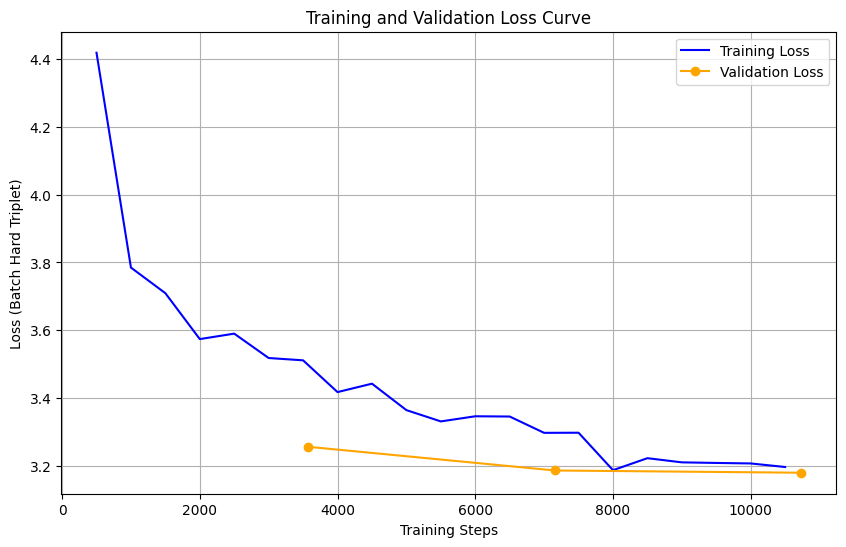

In [71]:
log_history = trainer.state.log_history
df_logs = pd.DataFrame(log_history)

plt.figure(figsize=(10, 6))
if 'loss' in df_logs.columns:
    train_logs = df_logs.dropna(subset=['loss'])
    plt.plot(train_logs['step'], train_logs['loss'], label='Training Loss', color='blue')

if 'eval_loss' in df_logs.columns:
    eval_logs = df_logs.dropna(subset=['eval_loss'])
    plt.plot(eval_logs['step'], eval_logs['eval_loss'], label='Validation Loss', marker='o', color='orange')

plt.title('Training and Validation Loss Curve')
plt.xlabel('Training Steps')
plt.ylabel('Loss (Batch Hard Triplet)')
plt.legend()
plt.grid(True)
plt.show()

In [72]:
print("Generating embeddings for Test set... (this takes a moment)")
X_train_emb = model.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model.encode(X_test.tolist(), show_progress_bar=True)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_emb, y_train.tolist())

# Make predictions on the test set
y_pred = clf.predict(X_test_emb)

Generating embeddings for Test set... (this takes a moment)


Batches: 100%|████████████████████████████████| 448/448 [00:34<00:00, 12.90it/s]


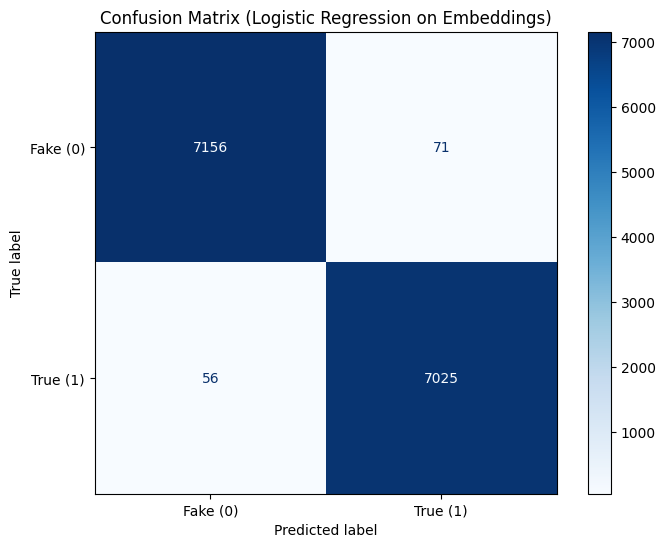


Classification Report:

              precision    recall  f1-score   support

    Fake (0)       0.99      0.99      0.99      7227
    True (1)       0.99      0.99      0.99      7081

    accuracy                           0.99     14308
   macro avg       0.99      0.99      0.99     14308
weighted avg       0.99      0.99      0.99     14308



In [73]:
cm = confusion_matrix(y_test.tolist(), y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake (0)", "True (1)"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title('Confusion Matrix (Logistic Regression on Embeddings)')
plt.show()
print("\nClassification Report:\n")
print(classification_report(y_test.tolist(), y_pred, target_names=["Fake (0)", "True (1)"]))

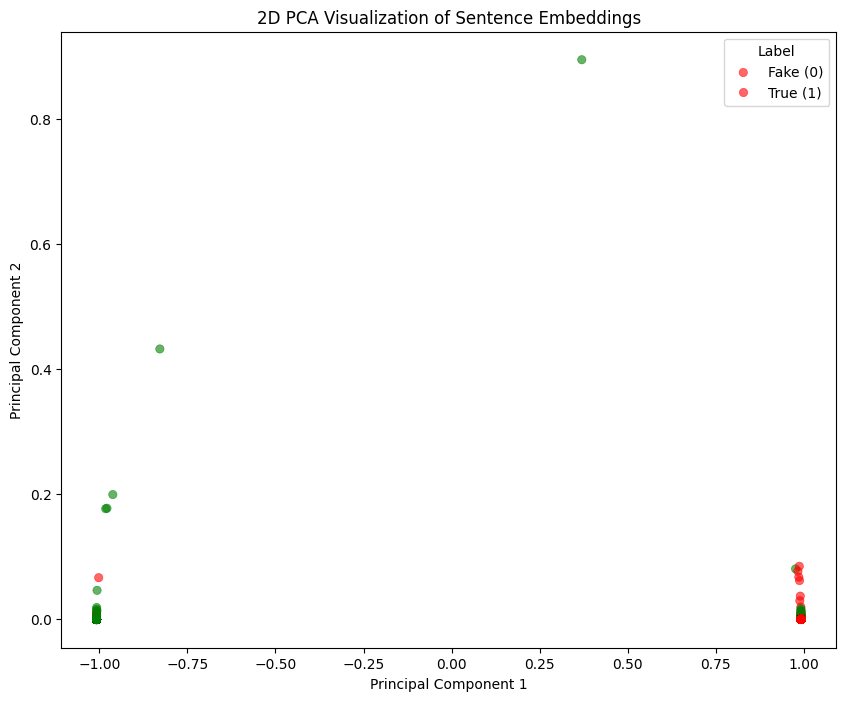

In [74]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_emb)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_test_pca[:, 0], 
    y=X_test_pca[:, 1], 
    hue=y_test.tolist(), 
    palette=["red", "green"], 
    alpha=0.6, 
    edgecolor=None
)
plt.title('2D PCA Visualization of Sentence Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Label', labels=['Fake (0)', 'True (1)'])
plt.show()